# APPLIED STATISTICS: 

In [1]:
# Import libraries.

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting:
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

# https://seaborn.pydata.org/tutorial.html
import seaborn as sns

# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Statistical functions.
# https://docs.scipy.org/doc/scipy/reference/stats.html
import scipy.stats as stats


# Data structures and data analysis.
# https://pandas.pydata.org/docs/reference/index.html
import pandas as pd




***

**Problem 1: Extending the lady tasting tea**


**AIM:** 

The aim of this study is to estimate the probability that a participant could correctly identify all milk first cups by random guessing in an extended Lady Tasting Tea experiment with 12 cups and to compare the probability with the original 8-cup experiment. 



**BACKGROUND:**

The [Lady Tasting Tea](https://en.wikipedia.org/wiki/Lady_tasting_tea) experiment was introduced by Ronald Fisher in The design of Experiments as an example of hypothesis testing. In the original experiment, a participant was asked to identify which cups of tea had milk poured first and which had tea poured first. 
Fisher used this experiment to show the [null hypothesis](https://statistics.laerd.com/statistical-guides/hypothesis-testing-3.php), which represents no effect or special ability and is tested against an alternative hypothesis which assumes the participant has some ability to correctly identify the cups. 

In hypothesis testing, results are evaluated using a p-value which represents the probability of observing a result as extreme as the one if the null hypothesis was true. A small p-value is evidence against the null hypothesis. The significance level (eg: 0.05) is the value used to decide whether to reject the null hypothesis.

In this study, the Lady Tasting Tea experiment is extended using a simulation to estimate the probability of correctly identifying all milk first cups by random guessing and the results are compared with the original 8-cup experiment. 


**Null Hypothesis($H_0$):** The participant has no special ability to distinguish between milk first and tea first cups and is guessing randomly.

**Alternative Hypothesis($H_1$):** The participant has an ability to identify the milk first cups better than random chance



In [2]:
# Parameters:

# Number of cups of tea in total. 
total_cups = 12

# Number of cups of tea with milk in first.
milk_first = 4

# Number of cups of tea with tea in first.
tea_first = 8

-   12 cups of tea prepared:
    -   4 cups with milk poured first.
    -   8 cups with tea poured first.
-   The participant must correctly identify all 4 milk first cups. 

How many ways are there to choose four cups from 12? 

In [3]:
# Total number of ways to choose cups with milk in first

math.comb(total_cups, milk_first) 

495

-   There are 495 possible sets of 4 cups with milk first to choose from 12 cups when order does not matter.
-   Only one of those sets is the correct set. 

The probability that a random guess picks the one correct set: 

$Probability = 1/495$



In [4]:
1/495




0.00202020202020202

**Simulation using NumPy:**

Simulates what would happen if the lady was guessing randomly.

-   Cups randomly shuffled many times(1,000,000)
-   Four cups were randomly selected in each simulation
-   A success was recorded when all selected cups were milk first.
-   The proportion of successes estimates the probability of a perfect guess by chance. 

In [5]:
# NumPy array:

cups = np.array([1]*milk_first + [0]*tea_first)
cups

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# Initialise counter to track number of successful guesses
success = 0 


In [7]:
# Number of simulations:
simulations = 1000000


*Run simulation:*

In [8]:
# for loop to randomly shuffle cups and make random guesses
for _ in range(simulations):
    np.random.shuffle(cups)
    guess = np.random.choice(total_cups, milk_first, replace=False)
    if np.all(cups[guess] == 1):
        success += 1

print("Simulated probability:", success / simulations)
print("Exact probability:", 1/495)


Simulated probability: 0.002037
Exact probability: 0.00202020202020202


The simulated probability closely matched the exact probability of 0.002 confirming that the simulation accurately represents random guessing. The probability is less than the significance level of alpha = 0.05. 

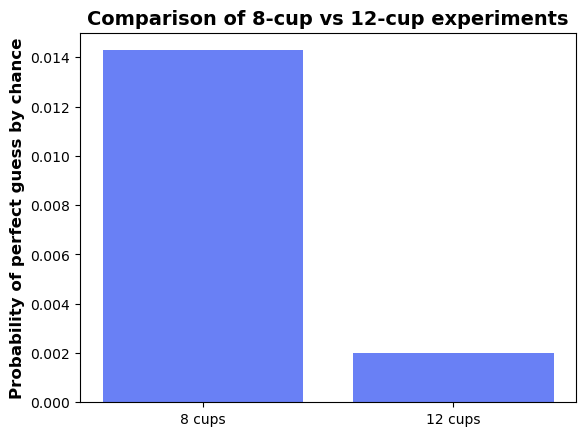

Original probability (8 cups): 0.014285714285714285
Extended probability (12 cups): 0.00202020202020202


In [9]:
# Plot comparison of original and extended experiment probabilities.

original_prob = 1/70      # 8 cups, 4 milk-first
extended_prob = 1/495     # 12 cups, 4 milk-first

plt.bar(["8 cups", "12 cups",], [original_prob, extended_prob], color=["#2A4BF23F"], alpha=0.7)
plt.ylabel("Probability of perfect guess by chance", fontsize=12, fontweight='bold', color='black')
plt.title("Comparison of 8-cup vs 12-cup experiments", fontsize=14, fontweight='bold', color='black')
plt.show()

print ("Original probability (8 cups):", original_prob)
print ("Extended probability (12 cups):", extended_prob)


-   As the total number of cups increases, the number of possible 4 cup combinations increases. Therefore, the chance of randomly choosing the exact four milk first cups decrease and the probability decreases.

The results show that the probability of correctly identifying all milk first cups by random guessing in the 12 cup experiment is very small. Since the estimated p-value is less than the significance value of 0.05, the null hypothesis is rejected providing strong evidence that the participant is not guessing randomly. 

Both the original 8 cup experiment and the extended 12 cup experiment reject the null hypothesis at the 0.05 significance level. However, the 12 cup experiment shows stronger evidence against the null hypothesis with a smaller p-value(0.002) compared to the 8 cup experiment (0.014). This shows that increasing the number of cups reduces the probability of a correct result occuring by chance. 

Based on the estimated probabilities, the significance level should be kept at 0.05. If the significance level was reduced to 0.01 to reduce the risk of a Type I error(false positive: an ability is detected when no real ability exists), the 12 cup result would still be significant but the 8 cup result would no longer meet the threshold and the null hypothesis would not be rejected which could increase the risk of a  Type II error (false negative) of not detecting an ability when one exists. 

<hr style="border-top: 2px dashed gray; border-bottom: none;">


**Problem 2: Normal Distribution:**


**AIM:**

The aim of this study is to show how sample standard deviations differ from the population standard deviation when taking many small samples from a standard normal distribution (mean=0, SD=1). The sample standard deviation (n-1, ddof=1) and population standard deviation(n, ddof=0) are calculated for 100,000 samples with sample size=10 and visualised using histograms.




**BACKGROUND:**

The [standard deviation(SD)](https://statistics.laerd.com/statistical-guides/measures-of-spread-standard-deviation.php) is a measure of variability that describes how spread out values in a dataset are from the mean. Along with the mean, it is often used to summarise continuous data. A larger SD indicates greater variability, while a smaller SD indicates that observations are more closely clustered around the mean. When variability is estimated from a sample, the SD can be calculated in two ways, as a population SD or as a sample SD. 

The population SD divides by *n*(number of observations) and is used when the dataset represents the entire population. When only a sample is available, the population mean is unknown and the sample SD is used. 
The sample SD divides by *n*-1([Bessel's correction](https://en.wikipedia.org/wiki/Bessel%27s_correction)) and 
adjusts for the loss of one degree of freedom that occurs when the population mean is estimated from the sample mean. Using the sample mean, causes the population SD formula to underestimate true variability for smaller sample sizes. Bessel's correction compensates for this bias, making the sample SD an unbiased estimator of the population SD.





In [10]:
# Generate 100000 samples from a normal distribution.

number_samples = 100000
sample_size = 10

samples = np.random.normal(loc=0, scale=1, size=(number_samples, sample_size))

# Calculate standard deviations
std_ddof1 = np.std(samples, axis=1, ddof=1)  # Sample SD
std_ddof0 = np.std(samples, axis=1, ddof=0)  # Population SD

# Calculate means
mean_ddof1 = np.mean(std_ddof1)
mean_ddof0 = np.mean(std_ddof0)


# https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html

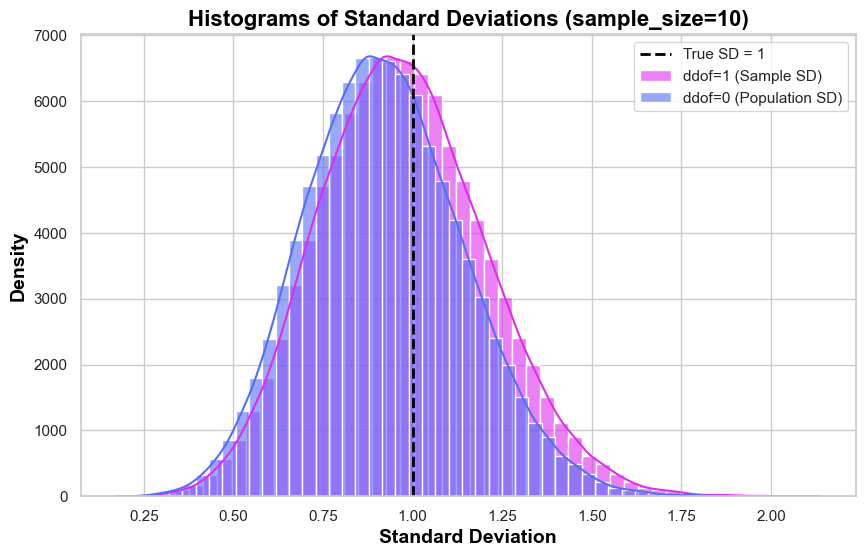

In [11]:
# Histograms of standard deviations: 

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))


# Plot histograms with KDE
sns.histplot(std_ddof1, bins=50, color="#E02BF0AE", label='ddof=1 (Sample SD)', kde=True, alpha=0.6)
sns.histplot(std_ddof0, bins=50, color="#566EF6", label='ddof=0 (Population SD)', kde=True, alpha=0.6)

# plot true standard deviation line
plt.axvline(1, color="black", linestyle='--', linewidth=2, label='True SD = 1')


plt.xlabel('Standard Deviation', fontsize=14, color='black', fontweight='bold')
plt.ylabel('Density', fontsize=14, color='black', fontweight='bold')
plt.title('Histograms of Standard Deviations (sample_size=10)', color='black', fontsize=16, fontweight='bold')
plt.legend()
plt.show()





The histograms show the distributions of standard deviations(SD) calculated from 100,000 samples of size 10 from a standard normal distribution. While the distributions of the sample SD(ddof=1) and the population SD(ddof=0) overlap, they are centered slightly to the left of the true population SD of 1. 

The population SD distribution is further to the left than the sample SD indicating an underestimation of variability when dividing by *n*. In contrast, the sample SD is centered closer to the true value showing how Bessel's correction reduces the bias when estimating the population SD from a smaller sample. Even with Bessels correction, individual sample SD's still vary around the true SD due to natural sampling variability. This variability decreases with larger sample sizes, giving more reliable estimates.

If the sample size increases, the variability of both the sample and population SD's would decrease because larger samples give more accurate estimates of the population mean with the bias becoming less important. The distributions would become narrower and more centered around the true SD of 1 and the difference between the two would be less noticeable.



<hr style="border-top: 2px dashed gray; border-bottom: none;">

**Problem 3: *t*-Tests**


**AIM:**

The aim of this study is to examine how the Type II error rate of an independent two-sample t-test changes as the true difference in means between two groups increases.

**BACKGROUND:**

A [*t*-test](https://en.wikipedia.org/wiki/Student%27s_t-test) is a statistical test used to determine if there is a significant difference between the means of two groups. For a *t*-test to be valid, certain assumptions must be met. The data in each group should be normally distributed, the samples should be independent and the variances of the two groups should be equal. 

*Null Hypothesis($H_0$):* the two group means are equal.

*Alternative Hypothesis($H_1$):* the two group means are not equal. 

A [Type II error(&beta;)](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors) occurs when the null hypothesis is false but is not rejected, meaning that a true difference between the group means is missed. The probability of avoiding a Type II error is known as statistical power(1 - &beta;). 






In [12]:
# Parameters.
sample_size = 100
alpha = 0.05      

# Calculate mean differences.
meandiff = np.arange(0.0, 1.1, 0.1)


In [13]:
# Simulation of Type 2 error rates.

type2_errors = []    #list 

# run simulation
for d in meandiff:
    type2_count = 0
    for _ in range(1000):
        group1 = np.random.normal(loc=0, scale=1, size=sample_size) # 
        group2 = np.random.normal(loc=d, scale=1, size=sample_size)
        tstat, pvalue = stats.ttest_ind(group1, group2)
        if pvalue >= alpha:
            type2_count += 1
    type2_errors.append(type2_count / 1000)

print("Type 2 Error Rates:", type2_errors)



Type 2 Error Rates: [0.935, 0.903, 0.692, 0.422, 0.177, 0.064, 0.012, 0.0, 0.0, 0.0, 0.0]


-   Two independent samples were generated.
-   The first sample was drawn from a std normal distribution with mean 0 and standard deviation 1. 
-   The second sample was drawn from a normal distribution with mean *d* and standard deviation 1, where d ranged from 0-1. 
'-  For each value of *d*, the simulation was repeated 1000 times. 
-   An independent two sample *t*-test was performed for each pair of samples. 
-   The null hypothesis was rejected when the p-value was less than 0.05.
-   The number of times the null hypothesis was not rejected was recorded and interpreted as the Type II error rate. 


In [14]:
# Plot table:

type2_table = pd.DataFrame({'Mean Difference': meandiff, 'Type 2 Error Rate(d)': type2_errors, 'power(1-β)': 1 - np.array(type2_errors) })
type2_table

,Mean Difference,Type 2 Error Rate(d),power(1-β)
0,0.0,0.935,0.065
1,0.1,0.903,0.097
2,0.2,0.692,0.308
3,0.3,0.422,0.578
4,0.4,0.177,0.823
5,0.5,0.064,0.936
6,0.6,0.012,0.988
7,0.7,0.000,1.000
8,0.8,0.000,1.000
9,0.9,0.000,1.000


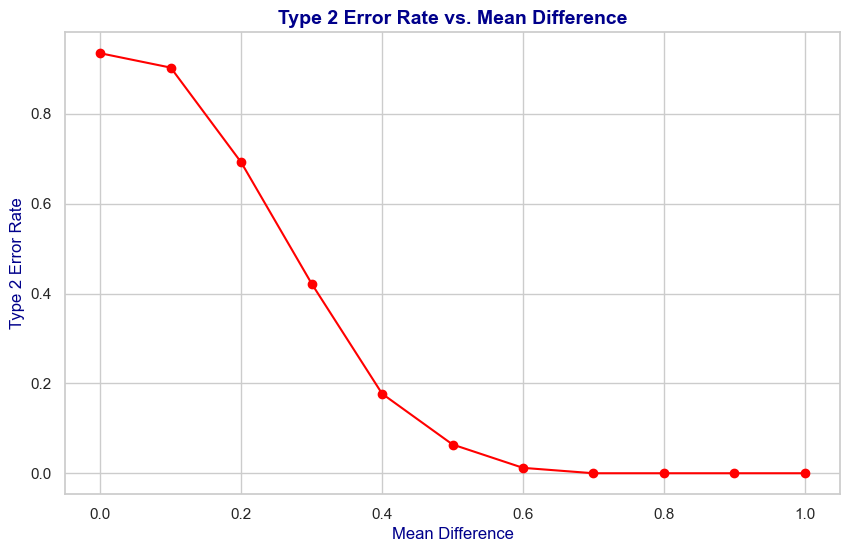

In [ ]:
# Plot:

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(meandiff, type2_errors, color='red', marker='o')
ax.set_xlabel('Mean Difference', color='darkblue')
ax.set_ylabel('Type 2 Error Rate', color='darkblue')
ax.set_title('Type 2 Error Rate vs. Mean Difference', fontsize=14, fontweight='bold', color='darkblue')
plt.show()


The results show that the Type II error rate of the independent two sample *t*-test decreases as the true difference in means between the two groups increases. When the mean difference *d* is small, there is increased overlap between the two groups making it difficult for the *t*-test to detect a true difference. As a result the probability of failing to reject a false null hypothesis is high. 

As *d* increases, the effect size (difference between the two means) becomes larger and the overlap between the distributions decreases. This makes it easier for the *t*-test to detect a significant difference between the means, leading to a decrease in the Type II error rate. For larger values of *d*, the Type II error rate gets closer to zero, indicating that the test almost always detects the true difference. When *d*=0, the null hypothesis is true and failures to reject it are expected in about 95% of cases, consistent with the significance level of &alpha;= 0.05.

As the true difference in means increase, statistical power increases close to 1, while the Type II error rate decreases close to 0. Larger effect sizes reduce overlap between groups improving the test ability to detect a true difference. 

<hr style="border-top: 2px dashed gray; border-bottom: none;">

 **Problem 4: ANOVA**



**AIM:**

The aim of this study is to compare the means of three groups to determine whether there are significant differences using one-way ANOVA  Three independent t-tests were also carried out to look at pairwise differences between groups. 

**BACKGROUND:**

[ANOVA](https://statistics.laerd.com/spss-tutorials/one-way-anova-using-spss-statistics.php) (Analysis of Variance) is a statistical method used to compare the means of two or more groups by analysing variation within and between groups to determine if there is significant difference between them. A one-way ANOVA tests all group means together using a single significance level, reducing the likelihood of false positives compared with performing multiple t-tests. If the ANOVA result is significant, post-hoc tests such as [Tukeys HSD](https://en.wikipedia.org/wiki/Tukey%27s_range_test) can be used to determine which specific group means differ.  


*Assumptions for valid ANOVA results:*
-   The data in each group are normally distributed
-   The standard deviations of the groups are equal 
-   The samples are independent. 

*Null Hypothesis($H_0$):* There is no difference in the means of all three groups. 

*Alternative Hypothesis($H_1$):* There is a difference in the means of all three groups.

*Post-hoc tests(Tukey HSD):*

-   Carried out after ANOVA shows a significant result.
-   Compares specific group means to identify which groups differ.
-   Results include the mean difference, p-value and confidence interval(CI).
-   The CI shows the range of values that likely contain the true difference between group means.
-   If the CI does not include 0, the difference is statistically significant. A significant p-value corresponds to a CI that excludes 0.




In [16]:
# Generate three independent samples.

np.random.seed(10)
group1 = np.random.normal(0.0, 1, 30)
group2 = np.random.normal(0.5, 1, 30)
group3 = np.random.normal(1.0, 1, 30)


In [ ]:
# Table:

df = pd.DataFrame({'Group 1': group1, 'Group 2': group2, 'Group 3': group3})


In [18]:
df.describe()

,Group 1,Group 2,Group 3
count,30.000000,30.000000,30.000000
mean,0.197991,0.616652,0.928524
std,1.054581,0.733988,1.123121
min,-1.977728,-0.439433,-1.131712
25%,-0.247086,0.140647,0.344318
50%,0.247071,0.430911,0.898486
75%,0.950025,1.023917,1.444012
max,2.384967,2.894704,3.467651


In [19]:
# one-way Anova
fstat, pvalue = stats.f_oneway(group1, group2, group3)
fstat, pvalue

# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html

(4.152510388485787, 0.018947461918568963)

-   p(0.019) < &alpha;(0.05) &rarr; $H_0$ rejected
-   At least one group mean is different from the others

In [20]:
# Tukey's HSD test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
res = pairwise_tukeyhsd(endog=df.melt()['value'], groups=df.melt()['variable'], alpha=0.05)
print(res)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
Group 1 Group 2   0.4187 0.2322 -0.1879 1.0253  False
Group 1 Group 3   0.7305 0.0141  0.1239 1.3371   True
Group 2 Group 3   0.3119 0.4412 -0.2947 0.9185  False
-----------------------------------------------------


*Group 1 vs group 3:* 
-  p-adj(0.01) < &alpha;(0.05) &rarr; means are significantly different &rarr; reject $H_0$


In [21]:
# Three independent two-sample t-tests.
tstatA, pvalueA = stats.ttest_ind(group1, group2)
tstatB, pvalueB = stats.ttest_ind(group1, group3)
tstatC, pvalueC = stats.ttest_ind(group2, group3)

# results
tstatA, pvalueA, tstatB, pvalueB, tstatC, pvalueC



(-1.7846985035638776,
 0.07954027203567579,
 -2.5971775520192595,
 0.011892592202204462,
 -1.2731628702457778,
 0.20803963291816832)

In [22]:
# T-test table.

table = pd.DataFrame({
    'Test': ['Group1 vs Group2', 'Group1 vs Group3', 'Group2 vs Group3'],
    't-statistic': [tstatA, tstatB, tstatC],    
    'p-value': [pvalueA, pvalueB, pvalueC]
})
table

significance = []
for p in table['p-value']:
    if p < 0.05:
        significance.append('Significant')
    else:
        significance.append('Not Significant')
table['Significance'] = significance
table

,Test,t-statistic,p-value,Significance
0,Group1 vs Group2,-1.784699,0.079540,Not Significant
1,Group1 vs Group3,-2.597178,0.011893,Significant
2,Group2 vs Group3,-1.273163,0.208040,Not Significant


The one-way ANOVA showed a statistically significant difference among the three groups (*p=0.019 < &alpha;=0.05*), indicating that at least one group mean differs from the others. ANOVA does not show which groups differ, therefore a post-hoc test using Tukeys HSD was carried out. 
Tukeys HSD showed that group 1 and group 3 differ significantly(*mean difference=0.731, p=0.014, 95% CI:0.124-1.337*) with group 1 having a higher mean.  The results for group 1 and group 2 (*mean difference=0.419, p=0.232*) and group 2 and group 3 (*mean difference=0.312, p=0.441*) were not significant. This indicates that the significant ANOVA result is due to the difference between group 1 and 3. 
The independent two-sample t-tests were consistent with the Tukey HSD results. The t-test for group 1 and group 3 was significant (p=0.012) while the other groups were not significant. However, t-tests do not adjust for multiple comparisons, which increases the chance of false positives. With three groups, there are three possible pairwise t-tests and each test carried out at the 0.05 significance level has a 5% chance of a Type I error.  


One-way ANOVA is preferred because it tests all group means together using a single significance level, reducing false positives. If the ANOVA result is significant, then post-hoc tests such as Tukeys HSD can then identify which groups differ while controlling the [family-wise error rate](https://en.wikipedia.org/wiki/Family-wise_error_rate). Therefore, ANOVA followed by Tukeys HSD gives a more reliable result when comparing multiple groups. 
 

### **End**
***